#**Imports**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config
set_config(transform_output='pandas')

#**Define Custom Functions**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOT
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray',colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap,colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  fig.tight_layout()
  plt.show()
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

#**Load the Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read in file from folder structure--this is the cleaned version (still has null values)
filename = '/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/titanic_dirty.csv'
df = pd.read_csv(filename)
df = df.set_index('PassengerId')
df.head()

,Unnamed: 0,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,,
1,0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,$7.25,NaN,S
2,1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,$71.28,C85,C
3,2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,$7.93,NaN,S
4,3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,$53.10,C123,S
5,4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,$8.05,NaN,S


#**Define X and Y and Train Test Split**

In [ ]:
# Drop irrelevant and high cardinality features
cols_drop = ['Ticket', 'Cabin']
# Create features matrix and target vector
X = df.drop(columns = [*cols_drop, 'Survived'])
y = df['Survived']
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

#**Create a Column Transformer for Preprocessing**

In [ ]:
# Categorical Preprocessing Pipeline
# Save list of column names
ohe_cols = X_train.select_dtypes('object').columns
print("OneHotEncoder Columns:", ohe_cols)
# Instantiate the individual preprocessors
impute_na = SimpleImputer(strategy='constant', fill_value = "Missing")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
# Making a ohe_tuple for ColumnTransformer
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)
# Numerical Preprocessing Pipeline
# Save list of column names
num_cols = X_train.select_dtypes("number").columns
print("Numeric Columns:", num_cols)
# instantiate preprocessors
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline(impute_median, scaler)
# Making a numeric tuple for ColumnTransformer
num_tuple = ('numeric', num_pipe, num_cols)
# Create the Column Transformer
preprocessor = ColumnTransformer([num_tuple, ohe_tuple],
                                 verbose_feature_names_out=False)

OneHotEncoder Columns: Index(['Name', 'Sex', 'SibSp', 'Fare', 'Embarked'], dtype='object')
Numeric Columns: Index(['Unnamed: 0', 'Pclass', 'Age', 'Parch'], dtype='object')


#**Make Model Pipeline and Fit on Training Data**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# Instantiate default KNN
knn = KNeighborsClassifier()

In [ ]:
# Define KNN model pipeline
knn_pipe = make_pipeline(preprocessor, knn)
# Fit the model on the training data
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Unnamed: 0', 'Pclass', 'Age', 'Parch'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Name', 'Sex', 'SibSp', 'Fare', 'Embarked'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('kneighborsclassifier', KNeighborsClassifier())])

#**Evaluate**

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       418
           1       0.80      0.76      0.78       261

    accuracy                           0.84       679
   macro avg       0.83      0.82      0.83       679
weighted avg       0.84      0.84      0.84       679



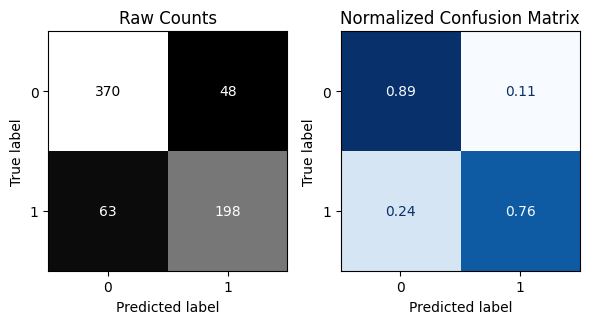


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       140
           1       0.78      0.70      0.74        87

    accuracy                           0.81       227
   macro avg       0.80      0.79      0.80       227
weighted avg       0.81      0.81      0.81       227



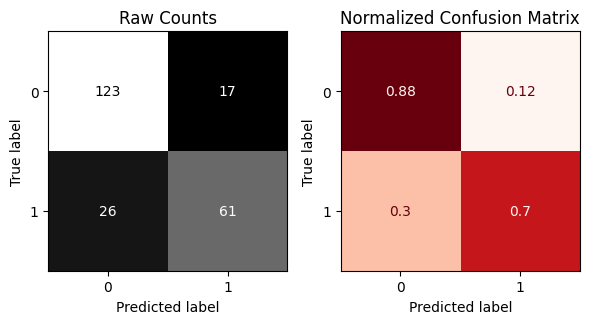

In [ ]:
# Obtain evaluation metrics using custom function
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

In [ ]:
# Making every other value from the range (odd values)
nneighbors_list = list(range(1,33,2))
nneighbors_list

#range(1, 33, 2) بتبدأ من 1 وبتزيد 2 كل مرة — يعني كلها فردية.
#list() بتحولها لقائمة نقدر نستخدمها.
#النتيجة: [1, 3, 5, 7, ..., 31] — 16 قيمة مختلفة لـ K.

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]

In [ ]:
# Get list of params for the knn model pipeline
knn_pipe.get_params()
#بيعرض كل الـ parameters الموجودة داخل الـ pipeline. السبب إننا محتاجين نعرف الاسم الصح للـ parameter — لاحظي إن الاسم مش بس n_neighbors بل أصبح
#kneighborsclassifier__n_neighbors لأنه داخل pipeline. لو كتبنا الاسم الغلط GridSearch ما رح يشتغل.


{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Unnamed: 0', 'Pclass', 'Age', 'Parch'], dtype='object')),
                                   ('categorical',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='Missing',
                                                                   strategy='constant')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                    

In [ ]:
# Create param grid
params={'kneighborsclassifier__n_neighbors': nneighbors_list}
#بنحدد إيش بدنا GridSearch يجرب — بنقوله "جرب كل قيم K اللي بالقائمة" وبنحطها في dictionary.

In [ ]:
# Instaniate GridSearchCV
gs = GridSearchCV(knn_pipe, params, verbose=True, n_jobs=-1)
# Fit gs on training data
gs.fit(X_train, y_train)
# Obtain best param value for K
gs.best_params_

#أولاً GridSearchCV — بنعمل object بيجرب كل قيم K اللي حددناها.
#verbose=True يعني بيطبع تقدمه وهو شغال. n_jobs=-1 يعني بيستخدم كل قوة المعالج للتسريع.
#ثانياً gs.fit() — بيجرب كل قيمة K مع 5-fold cross validation يعني كل قيمة K اتجربت 5 مرات على أجزاء مختلفة من البيانات — المجموع 16 قيمة × 5 = 80 تجربة.
#ثالثاً gs.best_params_ — بيعطيك أفضل قيمة K اللي لاقاها، وطلعت 21.

Fitting 5 folds for each of 16 candidates, totalling 80 fits


{'kneighborsclassifier__n_neighbors': 29}

In [ ]:
# Increasing max_columns to see full cv_results
pd.set_option('display.max_columns',50)
# Getting the cv_results as a dataframe
cv_results = pd.DataFrame(gs.cv_results_)
cv_results.head()

#نتائج كل التجارب الـ 80 محفوظة بـ gs.cv_results_ — بنحولها لـ DataFrame عشان نقدر نشوفها كجدول.
# pd.set_option('display.max_columns', 50) بس عشان نشوف كل الأعمدة ما تتقطع.

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kneighborsclassifier__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.105513,0.034769,0.087191,0.038538,1,{'kneighborsclassifier__n_neighbors': 1},0.735294,0.750000,0.713235,0.757353,0.755556,0.742288,0.016465,16
1,0.090516,0.028341,0.065446,0.017699,3,{'kneighborsclassifier__n_neighbors': 3},0.816176,0.779412,0.720588,0.750000,0.777778,0.768791,0.031986,15
2,0.115574,0.054972,0.104881,0.031276,5,{'kneighborsclassifier__n_neighbors': 5},0.808824,0.823529,0.735294,0.772059,0.800000,0.787941,0.031215,8
3,0.129667,0.041730,0.093424,0.016820,7,{'kneighborsclassifier__n_neighbors': 7},0.816176,0.816176,0.764706,0.742647,0.785185,0.784978,0.028808,10
4,0.116437,0.022156,0.081946,0.035738,9,{'kneighborsclassifier__n_neighbors': 9},0.838235,0.808824,0.727941,0.772059,0.807407,0.790893,0.037824,5


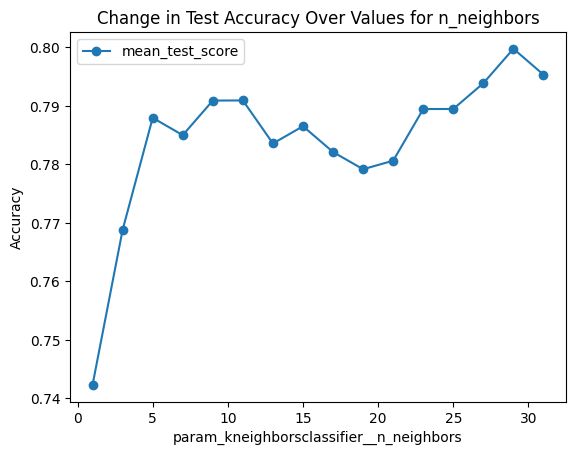

In [ ]:
# Plot Accuracy with various values for K
ax = cv_results.plot(x='param_kneighborsclassifier__n_neighbors',
                     y='mean_test_score', style='-o')
ax.set(ylabel="Accuracy", title='Change in Test Accuracy Over Values for n_neighbors');
print()

#بيرسم العلاقة بين قيم K على المحور الأفقي ودقة النموذج على المحور الرأسي.
#-o يعني خط مع نقاط. هاد الرسم بيبين كيف تغير K بأثر كبير على الدقة — عينياً تشوفي وين بتكون الدقة أعلى.

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       418
           1       0.85      0.62      0.71       261

    accuracy                           0.81       679
   macro avg       0.82      0.77      0.79       679
weighted avg       0.82      0.81      0.80       679



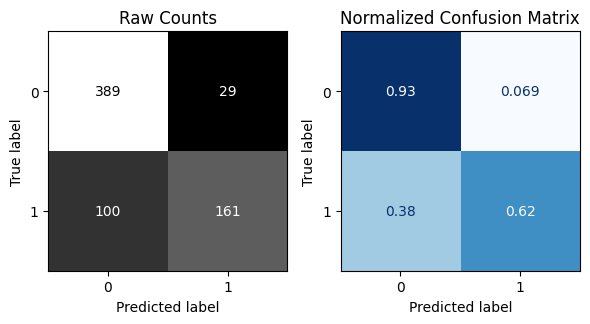


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.96      0.87       140
           1       0.90      0.61      0.73        87

    accuracy                           0.82       227
   macro avg       0.85      0.78      0.80       227
weighted avg       0.84      0.82      0.81       227



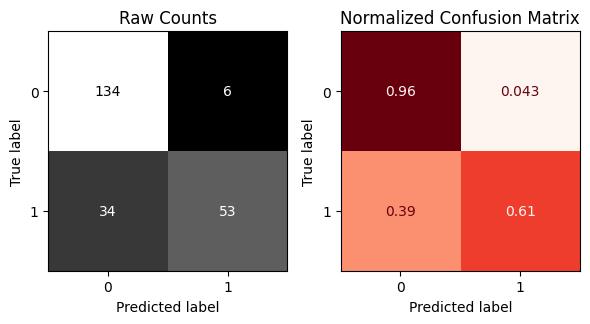

In [ ]:
# Obtain complete evaluation for best performing model (k = 21)
evaluate_classification(gs.best_estimator_, X_train, y_train, X_test, y_test)


#gs.best_estimator_ هو النموذج الأفضل اللي لاقاه GridSearch (يعني K=21).
#ئevaluate_classification دالة جاهزة بالكورس بتطبع كل مقاييس الدقة — accuracy، precision، recall، وغيرها — على Training وTest data مع بعض.

**بمعنى ثاني: K=5 شاطر بحفظ بيانات التدريب**

 **بس K=21 أذكى بالتعامل مع بيانات جديدة.**